In [72]:
import cellrank as cr
import scanpy as sc
import numpy as np
import h5py
import os
import pandas as pd
from scipy.sparse import csc_matrix

# follows https://nbisweden.github.io/workshop-scRNAseq/labs/scanpy/scanpy_07_trajectory.html

In [73]:
path = "/mnt/d/Starlng_paper/data/sergio_raw_5_tfs_seurat.h5ad"
adata = sc.read_h5ad(path)
adata.obs["total_counts"] = adata.X.sum(axis=1)
adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes = 5)
sc.pp.filter_genes(adata, min_cells = 5)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["log_normalized"] = adata.X.copy()
sc.pp.scale(adata)


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [74]:
adata
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30, random_state = 42)
sc.tl.umap(adata, random_state = 42)

In [75]:
sc.tl.leiden(adata, key_added = "leiden_clusters", random_state = 42)
sc.tl.draw_graph(adata, random_state = 42, init_pos = "X_umap")
sc.tl.paga(adata, groups="gt_clusters")

/tmp/ipykernel_14591/1586139834.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added = "leiden_clusters", random_state = 42)


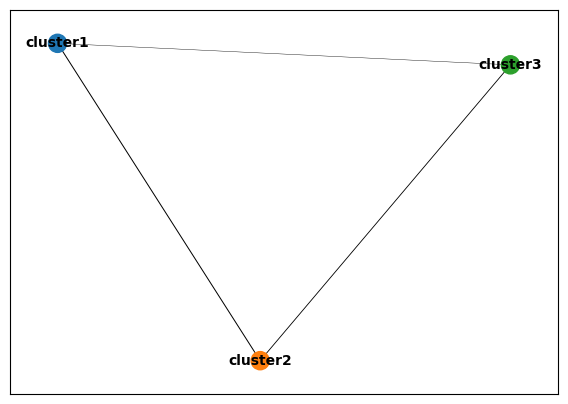

In [76]:
sc.pl.paga(adata)

In [77]:
sc.pp.neighbors(adata, n_neighbors=8, n_pcs=30, random_state=42)
sc.tl.draw_graph(adata, random_state=42, init_pos="X_umap")
sc.tl.paga(adata, groups="gt_clusters")

In [78]:
adata.uns["iroot"] = np.argmin(np.linalg.norm(adata.obsm["X_umap"] - adata[adata.obs["gt_clusters"] == "0"].obsm["X_umap"].mean(axis=0), axis=1))
sc.tl.dpt(adata)

/tmp/ipykernel_14591/1435648085.py:1: RuntimeWarning: Mean of empty slice
  adata.uns["iroot"] = np.argmin(np.linalg.norm(adata.obsm["X_umap"] - adata[adata.obs["gt_clusters"] == "0"].obsm["X_umap"].mean(axis=0), axis=1))
/home/andi/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


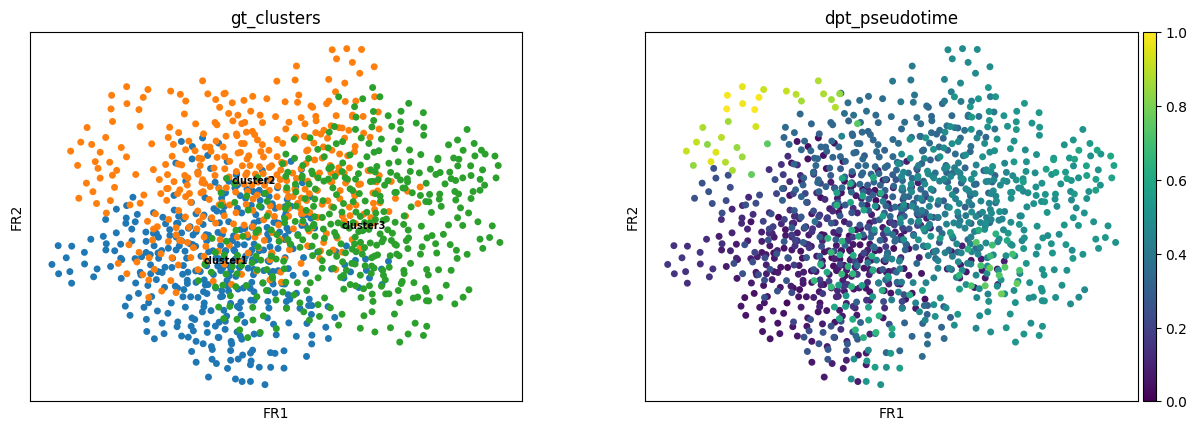

In [79]:
sc.pl.draw_graph(adata, color=['gt_clusters', 'dpt_pseudotime'], legend_loc='on data', legend_fontsize= 'x-small')

In [80]:
pt_kernel = cr.kernels.PseudotimeKernel(adata, time_key="dpt_pseudotime")
pt_kernel.compute_transition_matrix()

INFO     Computing transition matrix based on pseudotime                                                           


100%|██████████| 1200/1200 [00:00<00:00, 2437.79cell/s]

INFO         Finish (0.54s)                                                                                        


PseudotimeKernel[n=1200, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [81]:
pt_es = cr.estimators.GPCCA(pt_kernel)
pt_es.fit(cluster_key = "gt_clusters")

INFO     Computing eigendecomposition of the transition matrix                                                     


/tmp/ipykernel_14591/287073660.py:2: DeprecationWarning: `GPCCA.fit()` is deprecated and will be removed in CellRank 3.0. Use `GPCCA.compute_schur()` and `GPCCA.compute_macrostates()` directly.
  pt_es.fit(cluster_key = "gt_clusters")


INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.eigendecomposition`                                                                              
             Finish (0.16s)                                                                                        
WARNING  Unable to import `petsc4py` or `slepc4py`. Using `method='brandts'`                                       
WARNING  For `method='brandts'`, dense matrix is required. Densifying                                              
INFO     Computing Schur decomposition                                                                             
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                         

GPCCA[kernel=PseudotimeKernel[n=1200], initial_states=None, terminal_states=None]

In [82]:
pt_es.set_initial_states({"0": adata.obs_names[adata.obs["gt_clusters"] == "cluster1"]}, cluster_key = "gt_clusters", n_cells = 15)
pt_es.predict_terminal_states(allow_overlap=True)

INFO     Adding `adata.obs['init_states_fwd']`                                                                     
                `adata.obs['init_states_fwd_probs']`                                                               
                `.initial_states`                                                                                  
                `.initial_states_probabilities`                                                                    
                `.initial_states_memberships                                                                       
             Finish`                                                                                               
INFO     Adding `adata.obs['term_states_fwd']`                                                                     
                `adata.obs['term_states_fwd_probs']`                                                               
                `.terminal_states`                                      

GPCCA[kernel=PseudotimeKernel[n=1200], initial_states=['cluster1'], terminal_states=[np.str_('cluster1'), np.str_('cluster2'), np.str_('cluster3_1'), np.str_('cluster3_2')]]

In [ ]:
pt_es.compute_fate_probabilities()

INFO     Computing fate probabilities                                                                              


100%|██████████| 4/4 [00:00<00:00, 14.05/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (0.33s)                                                                                        


In [ ]:
# GammaGAM expects non-negative expression values.
adata.X = adata.layers["log_normalized"].copy()
model = cr.models.GAM(adata, n_knots = 6)

INFO     Computing trends using 8 core(s)                                                                          


/home/andi/.local/lib/python3.12/site-packages/pygam/distributions.py:490: RuntimeWarning: divide by zero encountered in log
  dev = 2 * ((y - mu) / mu - np.log(y / mu))
/home/andi/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/andi/.local/lib/python3.12/site-packages/pygam/pygam.py:1150: RuntimeWarning: invalid value encountered in scalar divide
  r2["explained_deviance"] = 1.0 - full_d.sum() / null_d.sum()
/home/andi/.local/lib/python3.12/site-packages/pygam/distributions.py:490: RuntimeWarning: divide by zero encountered in log
  dev = 2 * ((y - mu) / mu - np.log(y / mu))
/home/andi/.local/lib/python3.12/site-packages/pygam/pygam.py:1150: RuntimeWarning: invalid value encountered in scalar divide
  r2["explained_deviance"] = 1.0 - full_d.sum() / null_d.sum()
/home/andi/.local/lib/python3.12/site-packages/pygam/pygam.py:1151: RuntimeWarning: inval

INFO         Finish (1.43s)                                                                                        
INFO     Saving data to `adata.uns['lineage_cluster1_trend']`                                                      


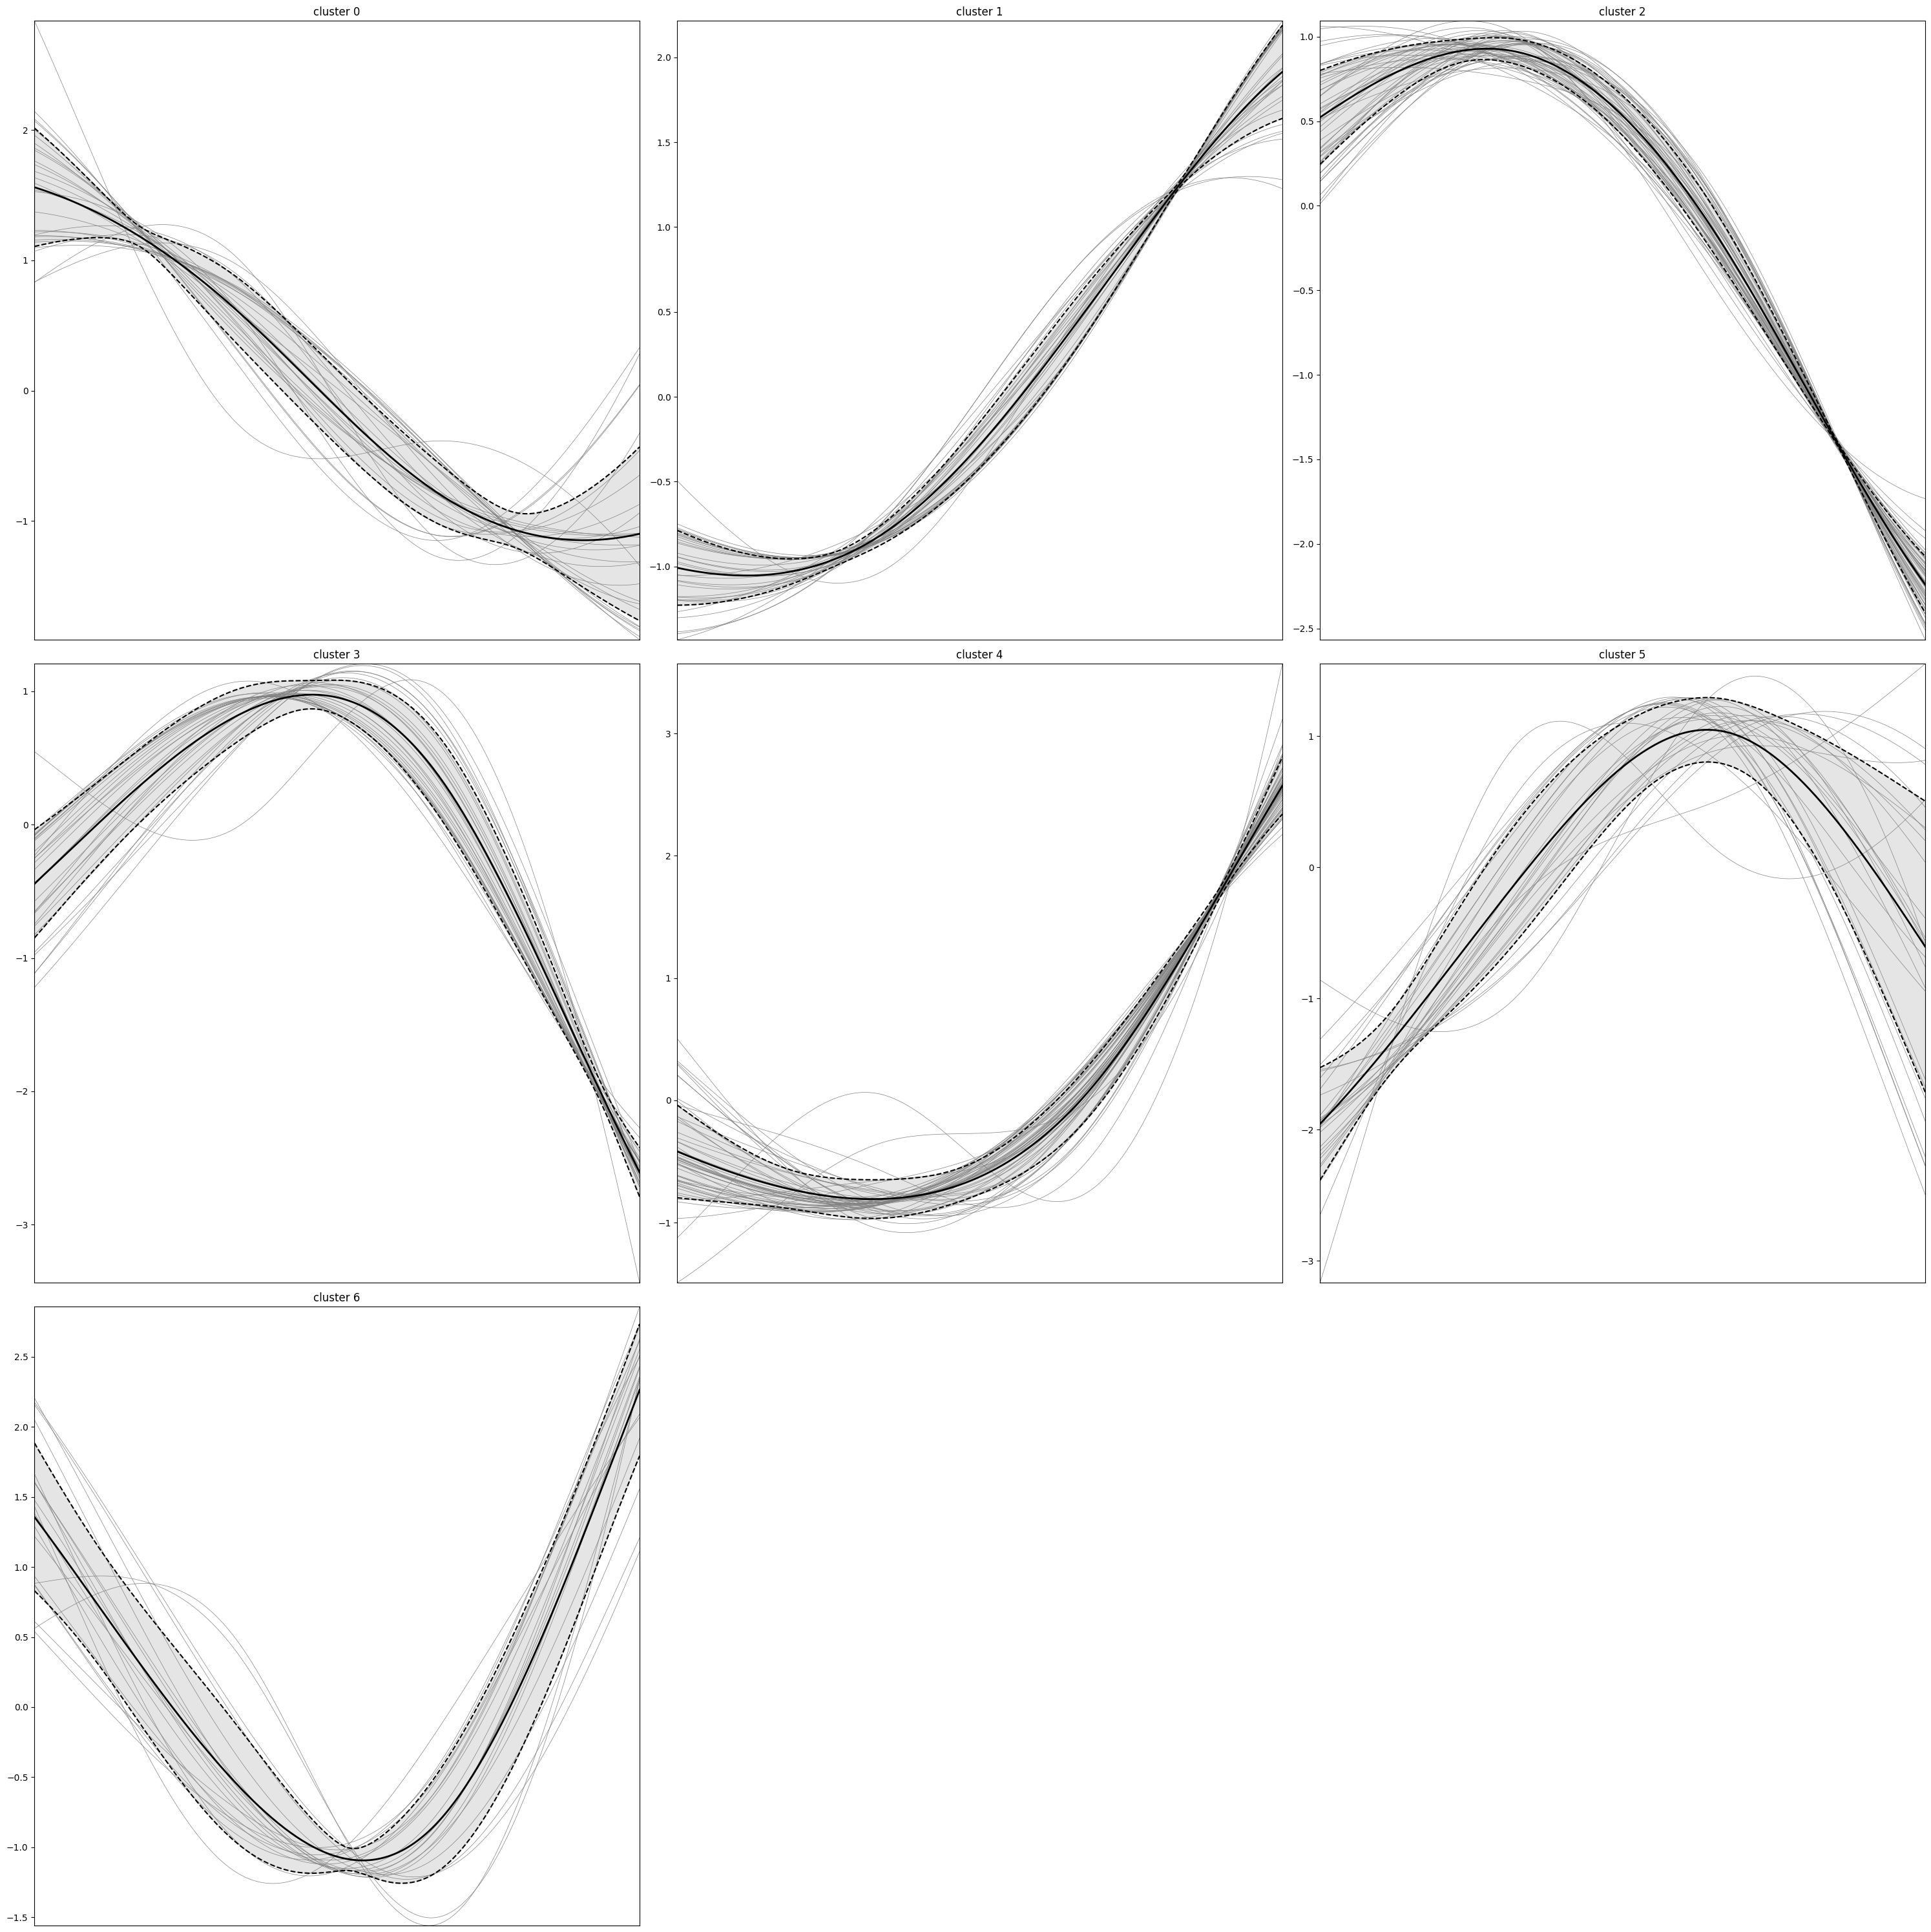

In [100]:
# Then we cluster trends based on driver genes.
trend_genes = adata.var_names
if len(trend_genes) < 2:
    trend_genes = adata.var_names

if len(trend_genes) < 2:
    raise ValueError("Need at least 2 genes for trend analysis. Check filtering/HVG settings.")

try:
    cr.pl.cluster_trends(
        adata,
        model=model,
        lineage="cluster1",
        genes=trend_genes,
        time_key="dpt_pseudotime",
        n_jobs=8,
        random_state=0,
        # pca_kwargs={"n_comps": 1, "svd_solver": "auto", "random_state": 0},
        clustering_kwargs={"resolution": 0.4, "random_state": 0},
        # neighbors_kwargs={"n_neighbors": 2, "random_state": 42},
        recompute=True,
    )
except Exception as e:
    print("cluster_trends skipped: dataset is too small/degenerate for PCA+KNN clustering after GAM fitting.")
    print(f"Original error: {e}")
    print("Try broadening the gene set or reducing filtering to get >=2 successfully fitted trends.")

In [109]:
adata.uns["lineage_cluster1_trend"]

AnnData object with n_obs × n_vars = 236 × 200
    obs: 'clusters'
    var: 'x_test'
    uns: 'pca', 'neighbors', 'clusters'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [125]:
list(map(str, adata.obs["term_states_fwd"].cat.categories.to_list()))

['cluster1', 'cluster2', 'cluster3_1', 'cluster3_2']